In [1]:
from matplotlib.colors import LinearSegmentedColormap

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

from _helper_functions import cb
import _helper_grammar_functions as jsgo

import statsmodels.api as sm
import pandas as pd 
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score)


In [2]:
infoDF=pd.read_csv('reference-files//syntax-families__with-example-seq.tsv',
                   sep='\t')

infoDF.head()

,syntax-family,example-seq
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...
1,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCAGATATTTAACGGAAGTTTTCGAAAAGGAAATTG...
2,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...
3,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...
4,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCGTTATCTCTAATTTCCTTTTTCGAAACGGAAGTT...


In [3]:
fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn)
sdf.head()

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,4,2,"(4, 2)","(2, 3)","(2, 5)","(4, 3)","(3, 3)","(1, 6)","(2, 4)",...,"(0, 3)","(4, 2)","(2, 3)","(3, 2)","(5, 2)","(4, 2)","(1, 6)","(1, 3)","(1, 1)","(1, 6)"
1,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,2,4,"(2, 4)","(2, 4)","(2, 6)","(1, 5)","(2, 2)","(1, 3)","(2, 3)",...,"(5, 0)","(1, 3)","(1, 4)","(1, 6)","(2, 3)","(3, 5)","(2, 2)","(0, 3)","(2, 4)","(1, 5)"
2,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,1,4,"(1, 4)","(2, 4)","(2, 2)","(3, 3)","(2, 2)","(1, 7)","(3, 4)",...,"(2, 7)","(0, 2)","(4, 2)","(2, 3)","(1, 6)","(2, 2)","(1, 2)","(1, 2)","(0, 6)","(2, 4)"
3,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,3,1,"(3, 1)","(3, 4)","(2, 5)","(4, 5)","(2, 2)","(2, 2)","(4, 3)",...,"(0, 2)","(1, 5)","(4, 4)","(1, 6)","(4, 4)","(2, 5)","(2, 2)","(1, 1)","(0, 5)","(0, 5)"
4,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,4,1,"(4, 1)","(2, 3)","(5, 6)","(3, 6)","(0, 6)","(2, 7)","(1, 4)",...,"(4, 2)","(1, 7)","(3, 3)","(2, 4)","(0, 4)","(2, 5)","(2, 3)","(3, 2)","(1, 5)","(1, 2)"


In [4]:
# syntax scores
fn='F05i-Syntax-Scores/3i-all-seqs.fillNaN.funcAnnotationCol=activity-label.effectSize=odds-ratio.pandas.dataframe.pickle'
ssdf=pd.read_pickle(fn).reset_index()
ssdf.head(1)

,seq,Ma,Ma-sum,Ma-sum-nafill1
0,AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGG...,[1.4241394089768973],1.424139,1.424139


In [5]:
# add syntax score
infoDF=infoDF.merge(ssdf,left_on='example-seq',right_on='seq',how='left')

In [6]:
# add syntax family info
infoDF=infoDF.merge(sdf,left_on='syntax-family',right_on='syntax-family')

In [7]:
infoDF['heatmap-loc']=infoDF.apply(lambda row:(row['n-func'],row['n-inert']),axis=1)

In [8]:
infoDF.head()

,syntax-family,example-seq,seq,Ma,Ma-sum,Ma-sum-nafill1,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,...,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99,heatmap-loc
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,"[2.768897348847782, 1.6656457008769634, 2.1987...",22.952603,22.952603,4,2,"(4, 2)","(2, 3)",...,"(4, 2)","(2, 3)","(3, 2)","(5, 2)","(4, 2)","(1, 6)","(1, 3)","(1, 1)","(1, 6)","(4, 2)"
1,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCAGATATTTAACGGAAGTTTTCGAAAAGGAAATTG...,CATCTGAAGCTCAGATATTTAACGGAAGTTTTCGAAAAGGAAATTG...,"[1.4956948640648746, 1.3442808841351088, 1.170...",9.534607,9.534607,2,4,"(2, 4)","(2, 4)",...,"(1, 3)","(1, 4)","(1, 6)","(2, 3)","(3, 5)","(2, 2)","(0, 3)","(2, 4)","(1, 5)","(2, 4)"
2,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,"[2.768897348847782, 1.6656457008769634, 1.3842...",33.514765,33.514765,1,4,"(1, 4)","(2, 4)",...,"(0, 2)","(4, 2)","(2, 3)","(1, 6)","(2, 2)","(1, 2)","(1, 2)","(0, 6)","(2, 4)","(1, 4)"
3,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,CATCTGAAGCTCAATATCTTAACGGAAGTTTTCGAAAAGGAAATTG...,"[2.768897348847782, 1.6656457008769634, 1.1707...",17.994353,17.994353,3,1,"(3, 1)","(3, 4)",...,"(1, 5)","(4, 4)","(1, 6)","(4, 4)","(2, 5)","(2, 2)","(1, 1)","(0, 5)","(0, 5)","(3, 1)"
4,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,CATCTGAAGCTCGTTATCTCTAATTTCCTTTTTCGAAACGGAAGTT...,CATCTGAAGCTCGTTATCTCTAATTTCCTTTTTCGAAACGGAAGTT...,"[1.1604463638091518, 1.6642542646653673, 1.182...",20.506711,20.506711,4,1,"(4, 1)","(2, 3)",...,"(1, 7)","(3, 3)","(2, 4)","(0, 4)","(2, 5)","(2, 3)","(3, 2)","(1, 5)","(1, 2)","(4, 1)"


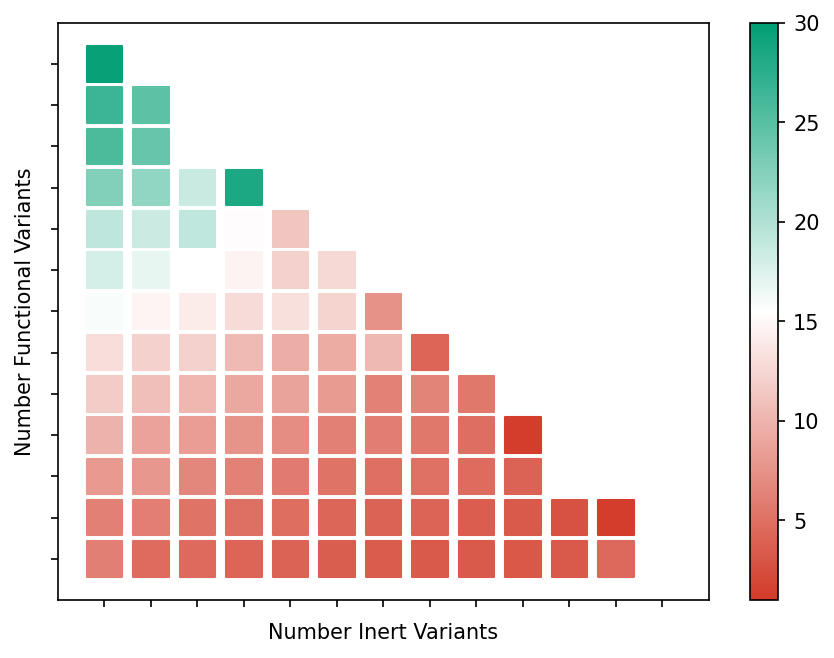

In [14]:
colorbar=True
    
##############################
# get data
##############################

syntaxscorecol='Ma-sum-nafill1'

aggSyntaxScoreFunc=np.mean
synFamBinOrder=infoDF['heatmap-loc'].unique()

motifData=[]
hmX=[]
hmY=[]
hmZ=[]

hmZfunc=np.mean

for bi in synFamBinOrder:

    # performing predictions on the test datdaset
    seqsInBin=infoDF.loc[infoDF['heatmap-loc']==bi,:].index.tolist()

    syntaxScoreList=infoDF.loc[seqsInBin,syntaxscorecol].tolist()
    aggSyntaxScore=aggSyntaxScoreFunc(syntaxScoreList)

    hmY.append(bi[0])
    hmX.append(bi[1])
    hmZ.append(aggSyntaxScore)
    if (bi[0],bi[1])==(0,12):
        print(bi[0],bi[1],aggSyntaxScore)

####################
# plot
####################
fig,ax=plt.subplots(1,figsize=(7,5),dpi=150)

# Create a custom colormap
cmap_name = 'custom_colormap'
colors = [cb['orangenature'], 'white', cb['green']]
n_bins = 1000  # Number of bins for the colormap
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)


mappable=ax.scatter(hmX,hmY,c=hmZ,marker='s',s=290,cmap=cm,vmin=1,vmax=30)



ax.set_xlim(-1,13)
ax.set_ylim(-1,13)
ax.set_ylabel('Number Functional Variants')
ax.set_xlabel('Number Inert Variants')

# plt.colorbar(mappable)

ticks=range(0,13)


ax.set_xticks(ticks,labels=labels)
ax.set_yticks(ticks,labels=labels)

# Add a colorbar
if colorbar:
    cbar = plt.colorbar(mappable)

